<a href="https://colab.research.google.com/github/nikolasluis/Aprendizado-de-M-quina-Supervisionado---Equipe-8/blob/main/Trabalho_Pr%C3%A1tico_%E2%80%94_Compara%C3%A7%C3%A3o_de_Algoritmos_de_Aprendizado_de_M%C3%A1quina_Supervisionado_Equipe_8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Trabalho Prático — Comparação de Algoritmos de Aprendizado de Máquina Supervisionado



##Objetivo

Aplicar os conceitos de aprendizado supervisionado abordados em aula: i) KNN, ii) SVM, iii) Árvores de Decisão e iv) MLP na resolução de um problema real de **Classificação** ou **Regressão**. O trabalho tem como foco a análise comparativa de desempenho entre algoritmos, bem como a discussão crítica dos resultados obtidos.

⚠️

O notebook entregue deve ser autocontido e totalmente executável. Isso significa que:

* Todas as bibliotecas necessárias devem ser importadas explicitamente no início do notebook.

* Exceto pelo carregamento (upload) do dataset (i.e data.zip), o restante código deve ser executável do início ao fim sem intervenções manuais, sem necessidade de ajustes, inserção de inputs, descompactações e/ou modificações de caminho de arquivos.

* Todos os arquivos necessários (por exemplo, dataset processado) devem estar acessíveis via link público para download.

* O notebook deve gerar todas as saídas esperadas automaticamente, incluindo métricas, gráficos e relatórios, sem dependência de ações externas.


⚠️ Exceto pelo carregamento do dataset (i.e data.zip), trabalhos que exigirem intervenção manual (como importação adicional de bibliotecas, inserção de inputs ou correções de código) serão desconsiderados na avaliação.



##Identificação da Equipe:

* **ID GRUPO CANVAS**:
* **Membro 1**:
* **Membro 2**:
* **Membro 3**:
* **Membro 4**:
* **Membro 5**:


⚠️ Além da identificação, **todos os membros do grupo** devem estar devidamente alocados no ambiente virtual (AVA), em:
**Pessoas → Grupos → Trabalho Final.**

⚠️ Apenas **uma submissão por grupo** é necessária. Entretanto, é imprescindível que **todos os integrantes estejam alocados** no respectivo grupo para que a atribuição do envio seja registrada corretamente.


##Seed

In [2]:
# Imports iniciais
import os
import random
import sklearn
import matplotlib.pyplot as plt
import kagglehub
import numpy as np
import pandas as pd
import seaborn as sns

from sklearn.datasets import make_blobs, make_classification
from sklearn.model_selection import train_test_split
from sklearn.inspection import DecisionBoundaryDisplay
from sklearn.svm import SVC as SVM
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from kagglehub import KaggleDatasetAdapter
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Definição de semente para reprodutibilidade
SEED = 42

np.random.seed(SEED)
random.seed(SEED)
os.environ["PYTHONHASHSEED"] = str(SEED)

#Definição e Descrição do Dataset

### Seleção do Dataset

Selecione um **dataset público** disponível no [Kaggle – Categoria Classification](https://www.kaggle.com/datasets?tags=13302-Classification), que contenha **rótulos (labels)**, caracterizando uma tarefa de **classificação binária** ou **multiclasse**.

O dataset escolhido deve apresentar **quantidade suficiente de instâncias e atributos** para permitir uma análise estatística e experimental significativa.

Caso o dataset tenha sido **pré-processado** (por exemplo: limpeza, seleção de atributos, codificação ou balanceamento), o **arquivo resultante** deve ser compartilhado em um link público (Google Drive, Dropbox, etc.), de modo que possa ser baixado e executado sem restrições.

> 🔗 **LINK PARA O DATASET:**
> *(Insira aqui o link direto para o dataset original ou processado)* <<==

⚠️ **Observação:** Trabalhos sem o link de acesso ao dataset não serão avaliados, pois impedem a reprodutibilidade do experimento.



---



##Descreva sucitamente o dataset (aplicação, desafios, etc)



---

#Preparação dos Dados

Nesta seção, desenvolva **rotinas** para o tratamento do dataset selecionado, contemplando as seguintes etapas:

* **Descompactação e Importação:** implemente a leitura direta do arquivo (CSV, XLSX, ZIP, etc.), garantindo o correto carregamento dos dados.
* **Limpeza e Pré-processamento:** realize as etapas necessárias de tratamento, como remoção de valores ausentes, codificação de variáveis categóricas, normalização ou padronização, e balanceamento das classes, quando aplicável.
* **Divisão dos Conjuntos:** separe o dataset em **treino, validação e teste**, utilizando o método **Holdout** de forma adequada à natureza do problema.
* **Análise Exploratória:** elabore **gráficos e estatísticas descritivas** que permitam compreender a distribuição das variáveis, a correlação entre atributos e o equilíbrio entre as classes.

**Descompactação e Importação**

In [3]:
file_path = 'heart.csv'

df = kagglehub.load_dataset(
  KaggleDatasetAdapter.PANDAS,
  'fedesoriano/heart-failure-prediction',
  file_path
)

/var/folders/g8/yv_f6b4n1v99gwczsdrrkvlc0000gn/T/ipykernel_415/3479902626.py:3: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  df = kagglehub.load_dataset(


Download already complete (35921 bytes).


**Limpeza e Pré-Processamento**

In [4]:
df.dropna(inplace=True)
df.drop_duplicates(inplace=True)

x = df.drop('HeartDisease', axis=1)
y = df['HeartDisease']

col_qualitativas = ['Sex', 'ChestPainType', 'RestingECG', 'ExerciseAngina', 'ST_Slope']
col_quantitativas =  ['Age', 'RestingBP', 'Cholesterol', 'MaxHR', 'Oldpeak', 'FastingBS']

preprocessador = ColumnTransformer([
    ('quantitativas', StandardScaler(), col_quantitativas),
    ('qualitativas', OneHotEncoder(drop='first'), col_qualitativas)
])

**Divisão dos conjuntos**

In [5]:
test_size = 0.2
random_state = SEED

x_train, x_test, y_train, y_test, = train_test_split(x, y, test_size=test_size, random_state=random_state)
x_train, x_val, y_train, y_val, = train_test_split(x_train, y_train, test_size=test_size, random_state=random_state)

print(f"Treino: {len(x_train)} | Validação: {len(x_val)} | Teste: {len(x_test)}")

Treino: 587 | Validação: 147 | Teste: 184


**Anánlise Exploratória**

*Correlação entre variavéis numéricas*

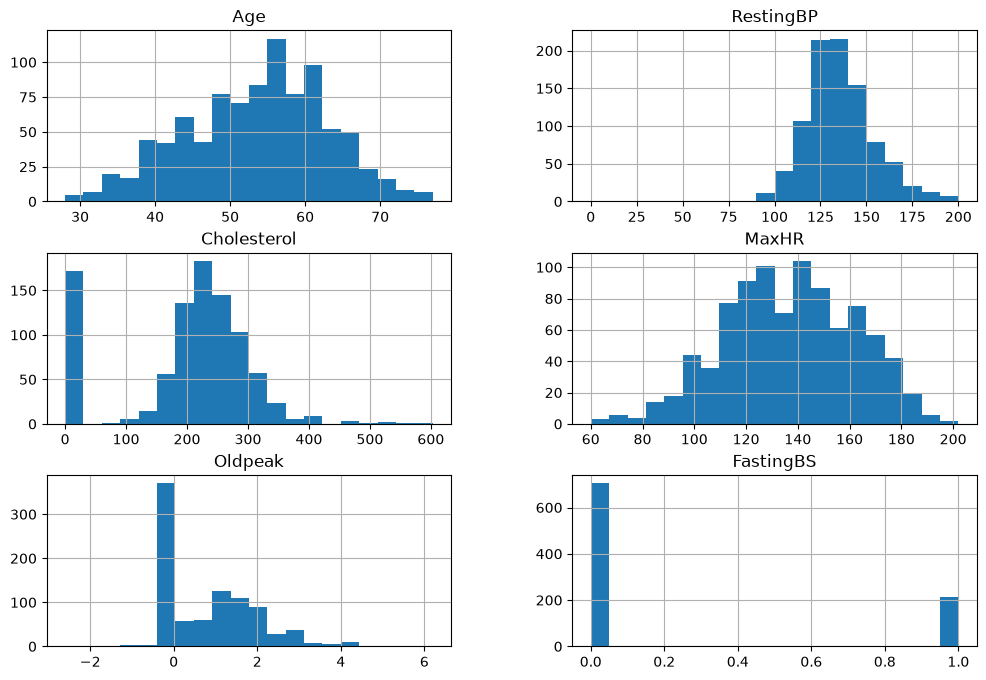

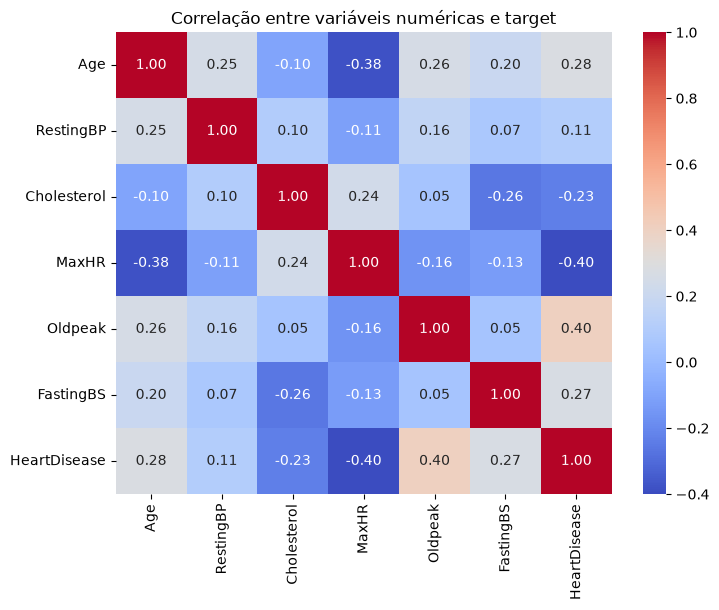

In [6]:
df[col_quantitativas].hist(bins=20, figsize=(12,8))

plt.figure(figsize=(8,6))
sns.heatmap(df[col_quantitativas + ['HeartDisease']].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlação entre variáveis numéricas e target')
plt.show()

*Distribuição de classes (equilíbrio entre as classes)*

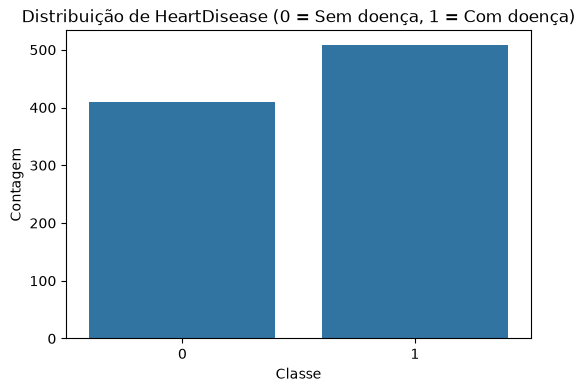

HeartDisease
1    0.553377
0    0.446623
Name: proportion, dtype: float64


In [7]:
plt.figure(figsize=(6,4))
sns.countplot(x='HeartDisease', data=df)
plt.title('Distribuição de HeartDisease (0 = Sem doença, 1 = Com doença)')
plt.xlabel('Classe')
plt.ylabel('Contagem')
plt.show()

# Proporções
print(df['HeartDisease'].value_counts(normalize=True))

---

#Implementação dos Modelos

Treinar e testar os seguintes algoritmos:

* K-Nearest Neighbors (KNN)

* Support Vector Machine (SVM)

* Decision Tree (Árvore de Decisão)

* Multi-Layer Perceptron (MLP)


**Implementação do modelo**

*Modelo RBF*

In [8]:
modelo_rbf = Pipeline([
    ('preprocess', preprocessador),
    ('svm', SVM(kernel='rbf'))
])
modelo_rbf.fit(x_train,y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocess', ...), ('svm', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](11,)","['Age','Sex','ChestPainType',...,'ExerciseAngina','Oldpeak','ST_Slope']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,11
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('quantitativas', ...), ('qualitativas', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passt

*Modelo Linear*

In [9]:
modelo_linear = Pipeline([
    ('preprocess', preprocessador),
    ('svm', SVM(kernel='linear'))
])
modelo_linear.fit(x_train,y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocess', ...), ('svm', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](11,)","['Age','Sex','ChestPainType',...,'ExerciseAngina','Oldpeak','ST_Slope']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,11
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('quantitativas', ...), ('qualitativas', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passt

*Modelo Polinomial*

In [10]:
modelo_poly = Pipeline([
    ('preprocess', preprocessador),
    ('svm', SVM(kernel='poly'))
])
modelo_poly.fit(x_train,y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocess', ...), ('svm', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](11,)","['Age','Sex','ChestPainType',...,'ExerciseAngina','Oldpeak','ST_Slope']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,11
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('quantitativas', ...), ('qualitativas', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passt

---

#Avaliação dos modelos


* Calcular e comparar as métricas: Acurácia, Precisão, Recall e F1-Score.


* Plotar e comentar as matrizes de confusão.


* Discutir o impacto dos hiperparâmetros e preprocessamentos aplicados.

Aqui você pode elaborar gráficos, analises de resultados da maneira que desejar. No entanto, espera-se uma breve discussão dos resultados e análises críticas.


*Modelo RBF*

              precision    recall  f1-score   support

           0       0.83      0.83      0.83        77
           1       0.88      0.88      0.88       107

    accuracy                           0.86       184
   macro avg       0.85      0.85      0.85       184
weighted avg       0.86      0.86      0.86       184



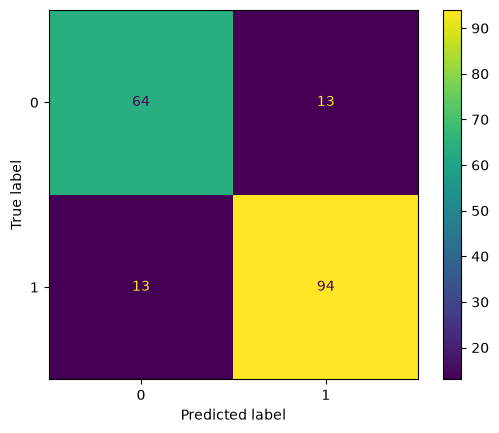

In [11]:
y_pred = modelo_rbf.predict(x_test)

print(classification_report(y_test,y_pred))
cm = confusion_matrix(y_test, y_pred, labels=modelo_rbf.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                               display_labels=modelo_rbf.classes_)
disp.plot()

plt.show()

MLP

In [ ]:
from sklearn.neural_network import MLPClassifier

mlp = MLPClassifier(
        hidden_layer_sizes=(10, 10, 10),  # 3 hidden layers
        activation="relu",
        solver="adam",
        learning_rate_init=0.001,
        max_iter=2000,
        random_state=42, 
        verbose=True, 
        n_iter_no_change=20)

pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("mlp", MLPClassifier(
        max_iter=5000,
        random_state=42
    ))
])

param_grid = {
    "mlp__hidden_layer_sizes": [
        (2,),(4,),(6,),(8,),(12,),(16,),
        (2, 2),
        (4, 2),(4, 4),
        (6, 2),(6, 4),(6, 6),(6, 8),
        (8, 4),(8, 8),(8, 12),
        (12, 6),(12, 12),(12, 16),
        (16, 8),(16, 16),(16, 24),
        (24, 12),(24, 24),(24, 32),
        (2,2,2),(4,4,4),(6,6,6),
        (8,8,8),(12,12,12),
        (10, 10, 10),(16, 16, 16),(24, 24, 24),
        (2,2,2,2),(4,4,4,4),(6,6,6,6),
        (8,8,8,8),(12,12,12,12),
        (10, 10, 10, 10),(16, 16, 16, 16),(24, 24, 24, 24)
    ],
    "mlp__activation": ['relu', 'identity', 'logistic', 'tanh'],
    "mlp__solver": ['lbfgs', 'adam'],
    "mlp__alpha": [0.0001, 0.001, 0.01],
    "mlp__learning_rate_init": [0.001, 0.01]
}

In [ ]:
from sklearn.model_selection import GridSearchCV, StratifiedKFold

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)


grid_search = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    scoring="accuracy",
    cv=cv,
    n_jobs=-1,
    verbose=2,
    refit=True,
    return_train_score=True
)

grid_search.fit(x_train,y_train)

In [ ]:
best_model = grid_search.best_estimator_

y_pred = best_model.predict(x_test)

print(classification_report(y_test,y_pred))
cm = confusion_matrix(y_test, y_pred, labels=best_model.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                               display_labels=best_model.classes_)
disp.plot()

plt.show()

---

# Discussão, análise crítica e conclusão


* Apresentar e discutir o modelo de melhor desempenho e justificar tecnicamente

* Apresentar e discutir as limitações e possíveis desafios.


---

#Submissão

O notebook desenvolvido no Google Colab deve ser exportado em formato PDF por meio da opção:
Arquivo → Imprimir → Salvar como PDF.

É obrigatório que o arquivo PDF contenha todas as células processadas, exibindo os resultados, gráficos e métricas gerados durante a execução. Trabalhos submetidos com células não executadas ou sem resultados visíveis não serão avaliados.

A submissão deve seguir as seguintes orientações:

O envio deve ser feito por apenas um integrante do grupo, previamente cadastrado no AVA.

O notebook Colab original deve estar compartilhado publicamente (ou com permissão de visualização) e o link de acesso deve ser inserido abaixo:

🔗 LINK PARA O COLAB:
(Insira aqui o link de compartilhamento do notebook no Google Colab)

Essa etapa permite ao professor a verificação do código-fonte completo, dos procedimentos de análise e da reprodutibilidade dos resultados.


BOM TRABALHO!! ✅ !!!

---
